# Stage 4 — linear baseline + evaluation harness

This notebook is the Stage 4 demo surface. It fits a seasonal-naive baseline and an OLS weather-only regression against the Stage 3 feature table, runs the rolling-origin evaluator against both, and prints the three-way comparison against NESO's own day-ahead forecast.

### Why losing to NESO is the expected outcome

NESO's published day-ahead forecast incorporates calendar effects, embedded generation, and a forecaster's prior on atypical days. The Stage 4 linear model has five weather columns and nothing else. Losing cleanly here is the pedagogical payoff: Stage 5 adds calendar features and the without/with comparison lands with force precisely because the Stage 4 floor is honest about what "temperature and nothing else" can do.

### What this notebook does

1. Loads the Stage 3 feature table via `assembler.load`.
2. Fits `bristol_ml.models.naive.NaiveModel` and prints its `ModelMetadata`.
3. Fits `bristol_ml.models.linear.LinearModel` and prints `results.summary()` — the statsmodels demo payoff.
4. Runs `harness.evaluate` for both models and displays the per-fold metric table.
5. If the NESO day-ahead forecast cache is warm, runs `benchmarks.compare_on_holdout` and prints the three-way table. Otherwise it skips with a note.
6. Draws the linear model's residual diagnostic and a 48-hour forecast overlay.

Acceptance criterion 6: under 120 seconds with warm caches on a laptop (plan D7). The splitter uses `step=168` (weekly stride) to keep the notebook inside that budget; the CLI (`python -m bristol_ml.train`) runs the full daily-stride configuration.

In [7]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.parent != REPO_ROOT and not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)  # cache_dir values resolve against cwd

import matplotlib.dates as mdates  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402

from bristol_ml import load_config  # noqa: E402
from bristol_ml.evaluation.benchmarks import compare_on_holdout  # noqa: E402
from bristol_ml.evaluation.harness import evaluate  # noqa: E402
from bristol_ml.evaluation.metrics import METRIC_REGISTRY  # noqa: E402
from bristol_ml.features import assembler  # noqa: E402
from bristol_ml.ingestion import neso_forecast as neso_forecast_mod  # noqa: E402
from bristol_ml.models.linear import LinearModel  # noqa: E402
from bristol_ml.models.naive import NaiveModel  # noqa: E402

# Plan D7: narrow the first fold's training window to 30 days (720 h) and
# stride weekly (168 h) so the notebook finishes in under 120 s. The CLI
# path (`python -m bristol_ml.train`) inherits the defaults (one-year train,
# daily stride) for reporting-quality output.
cfg = load_config(
    config_path=REPO_ROOT / "conf",
    overrides=[
        "evaluation.rolling_origin.min_train_periods=720",
        "evaluation.rolling_origin.step=168",
    ],
)
assert cfg.features.weather_only is not None, "features.weather_only not resolved"
assert cfg.evaluation.rolling_origin is not None, "evaluation.rolling_origin not resolved"
assert cfg.model is not None, "default model not resolved"

feature_path = cfg.features.weather_only.cache_dir / cfg.features.weather_only.cache_filename
features = assembler.load(feature_path).set_index("timestamp_utc")
print(f"Feature table: rows={len(features):,}  columns={list(features.columns)}")
print(f"Window: {features.index[0]} → {features.index[-1]}")

Feature table: rows=8,760  columns=['nd_mw', 'tsd_mw', 'temperature_2m', 'dew_point_2m', 'wind_speed_10m', 'cloud_cover', 'shortwave_radiation', 'neso_retrieved_at_utc', 'weather_retrieved_at_utc']
Window: 2023-01-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00


## Seasonal-naive baseline

The naive model is the credible-but-beatable floor. The default strategy `same_hour_last_week` predicts `y_{t-168}`; it captures GB's dominant weekly seasonality without any training loop. Fitting it is literally a dataframe copy.

`ModelMetadata` (plan D3 / DESIGN §7.3) is the provenance record attached to every fitted model in the project — name, feature columns, fit timestamp, hyperparameters — the minimum information needed to reason about a saved artefact without re-loading heavy state.

In [8]:
from conf._schemas import LinearConfig, NaiveConfig

naive = NaiveModel(NaiveConfig(strategy="same_hour_last_week"))
# Fit on the full feature table so the notebook's later 48 h overlay can
# call predict() on a single test slice; the harness in Cell 5 re-fits
# fold-by-fold so this global fit does not bias the evaluation.
naive.fit(features, features["nd_mw"])
print(naive.metadata.model_dump_json(indent=2))

{
  "name": "naive-same-hour-last-week",
  "feature_columns": [
    "nd_mw",
    "tsd_mw",
    "temperature_2m",
    "dew_point_2m",
    "wind_speed_10m",
    "cloud_cover",
    "shortwave_radiation",
    "neso_retrieved_at_utc",
    "weather_retrieved_at_utc"
  ],
  "fit_utc": "2026-04-20T08:21:20.398536Z",
  "git_sha": null,
  "hyperparameters": {
    "strategy": "same_hour_last_week",
    "target_column": "nd_mw"
  }
}


## Linear regression (OLS) — the demo payoff

`LinearModel` wraps `statsmodels.regression.linear_model.OLS`. `fit_intercept=True` (the default) adds a constant column automatically via `sm.add_constant`. The `results.summary()` block below is the reason for plan D2: statsmodels exposes coefficients with standard errors, t-statistics, R², AIC/BIC and residual diagnostics out of the box — the richer output justifies the dependency pick over sklearn's `LinearRegression`.

In [9]:
linear = LinearModel(LinearConfig())
linear.fit(features, features["nd_mw"])
print(linear.results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     456.5
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:21:20   Log-Likelihood:                -87597.
No. Observations:                8760   AIC:                         1.752e+05
Df Residuals:                    8754   BIC:                         1.752e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                2.744e+04    

## Rolling-origin evaluation — per-fold metrics

`harness.evaluate` calls `model.fit` / `model.predict` once per rolling-origin fold and returns a long-form DataFrame with one row per fold. Columns: fold index + three fold-boundary timestamps + one column per metric.

The four metrics (`mae`, `mape`, `rmse`, `wape`) are defined in `bristol_ml.evaluation.metrics` — pure `(y_true, y_pred) -> float` callables. MAPE and WAPE are reported as fractions (0.02 = 2 %); DESIGN §5.3 keeps the ×100 decision to downstream formatting.

In [10]:
metric_names = (
    cfg.evaluation.metrics.names if cfg.evaluation.metrics is not None else tuple(METRIC_REGISTRY)
)
metric_fns = [METRIC_REGISTRY[name] for name in metric_names]
split_cfg = cfg.evaluation.rolling_origin

# Fresh model instances — the harness calls fit() once per fold, and we
# do not want the Cell 3 / 4 global fits carried across to the evaluator.
naive_per_fold = evaluate(
    NaiveModel(NaiveConfig(strategy="same_hour_last_week")),
    features,
    split_cfg,
    metric_fns,
)
linear_per_fold = evaluate(
    LinearModel(LinearConfig()),
    features,
    split_cfg,
    metric_fns,
)

print(f"Naive mean per metric:  {naive_per_fold[list(metric_names)].mean().to_dict()}")
print(f"Linear mean per metric: {linear_per_fold[list(metric_names)].mean().to_dict()}")
linear_per_fold.head()

2026-04-20 09:21:20.544 | INFO     | bristol_ml.evaluation.harness:evaluate:160 - Evaluator fold 0 train_len=720 test_len=24 metrics={'mae': 5261.958333333333, 'mape': 0.18107596745288781, 'rmse': 5354.76977018309, 'wape': 0.17620622296637364}
2026-04-20 09:21:20.545 | INFO     | bristol_ml.evaluation.harness:evaluate:160 - Evaluator fold 1 train_len=888 test_len=24 metrics={'mae': 2932.25, 'mape': 0.09388684479596938, 'rmse': 3062.0531646810664, 'wape': 0.0894121772539812}
2026-04-20 09:21:20.547 | INFO     | bristol_ml.evaluation.harness:evaluate:160 - Evaluator fold 2 train_len=1056 test_len=24 metrics={'mae': 1773.375, 'mape': 0.056759123431990355, 'rmse': 1876.0009661511372, 'wape': 0.05716622812496222}
2026-04-20 09:21:20.548 | INFO     | bristol_ml.evaluation.harness:evaluate:160 - Evaluator fold 3 train_len=1224 test_len=24 metrics={'mae': 1369.7083333333333, 'mape': 0.04969685689615921, 'rmse': 1545.8307232682369, 'wape': 0.04546888010423554}
2026-04-20 09:21:20.549 | INFO    

Naive mean per metric:  {'mae': 1867.322048611111, 'mape': 0.0704236024252643, 'rmse': 2157.8038326224755, 'wape': 0.06939823133373689}
Linear mean per metric: {'mae': 4538.317477118517, 'mape': 0.17215026813331735, 'rmse': 5227.682275971315, 'wape': 0.16659573773438122}


,fold_index,train_end,test_start,test_end,mae,mape,rmse,wape
0,0,2023-01-30 23:00:00+00:00,2023-01-31 00:00:00+00:00,2023-01-31 23:00:00+00:00,5058.258021,0.179683,5602.799253,0.169385
1,1,2023-02-06 23:00:00+00:00,2023-02-07 00:00:00+00:00,2023-02-07 23:00:00+00:00,4801.493199,0.150671,5349.245412,0.146410
2,2,2023-02-13 23:00:00+00:00,2023-02-14 00:00:00+00:00,2023-02-14 23:00:00+00:00,4964.803005,0.167043,5526.097435,0.160045
3,3,2023-02-20 23:00:00+00:00,2023-02-21 00:00:00+00:00,2023-02-21 23:00:00+00:00,3887.038787,0.139972,4576.141354,0.129034
4,4,2023-02-27 23:00:00+00:00,2023-02-28 00:00:00+00:00,2023-02-28 23:00:00+00:00,5253.418311,0.162807,5755.892039,0.162562


## Three-way benchmark — naive, linear, NESO

If the NESO day-ahead forecast archive has been cached locally (`python -m bristol_ml.ingestion.neso_forecast --cache auto`), this cell runs the three-way comparison. If not, it skips with a note — the archive is a one-off slow download (several minutes over NESO's rate-limited CKAN API) and is optional for the notebook demo.

`benchmarks.compare_on_holdout` aligns the half-hourly NESO series to hourly via plan D4's `mean` rule, then scores every row on the intersection of the model test periods with the forecast archive's coverage.

In [11]:
forecast_cache = (
    cfg.ingestion.neso_forecast.cache_dir / cfg.ingestion.neso_forecast.cache_filename
    if cfg.ingestion.neso_forecast is not None
    else None
)
if forecast_cache is not None and forecast_cache.exists():
    neso_df = neso_forecast_mod.load(forecast_cache)
    benchmark_table = compare_on_holdout(
        {
            "naive": NaiveModel(NaiveConfig(strategy="same_hour_last_week")),
            "linear": LinearModel(LinearConfig()),
        },
        features,
        neso_df,
        split_cfg,
        metric_fns,
        aggregation=(
            cfg.evaluation.benchmark.aggregation if cfg.evaluation.benchmark is not None else "mean"
        ),
    )
    print(benchmark_table.to_string(float_format=lambda v: f"{v:.3f}"))
else:
    print(
        "NESO forecast cache not populated — run `python -m bristol_ml.ingestion.neso_forecast "
        "--cache auto` to fetch the archive, then re-run this cell."
    )
    benchmark_table = None

NESO forecast cache not populated — run `python -m bristol_ml.ingestion.neso_forecast --cache auto` to fetch the archive, then re-run this cell.


## Residuals and a 48-hour forecast overlay

The residual plot is a smell test: a weather-only OLS that systematically mis-predicts weekends or holidays will leak that structure into the residuals. The Stage 4 intent notes this explicitly — the pattern is the hook for Stage 5's calendar features.

The 48-hour overlay picks a window from the last test fold and draws actuals alongside every available forecast (naive, linear, NESO if present). Local time (`Europe/London`) on the display axis; arithmetic stays in UTC.

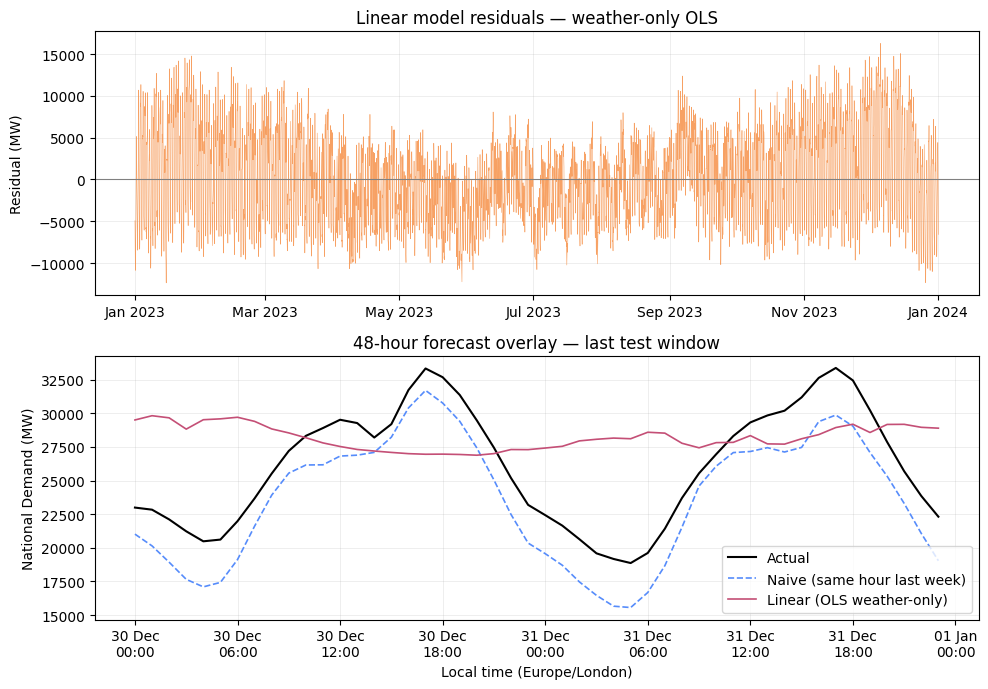

In [12]:
residuals = features["nd_mw"] - linear.results.fittedvalues
display_ts = features.index.tz_convert("Europe/London")

fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(10, 7), sharex=False)

ax_top.plot(display_ts, residuals, linewidth=0.4, color="C1", alpha=0.8)
ax_top.axhline(0.0, color="grey", linewidth=0.8)
ax_top.set_ylabel("Residual (MW)")
ax_top.set_title("Linear model residuals — weather-only OLS")
ax_top.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax_top.grid(True, alpha=0.3)

# Draw the last 48 h of the final test fold.  Every available model
# predicts on the same slice so the three lines are directly comparable.
window_end = features.index[-1]
window_start = window_end - pd.Timedelta(hours=47)
window = features.loc[window_start:window_end]
window_display = window.index.tz_convert("Europe/London")

ax_bottom.plot(window_display, window["nd_mw"], color="black", linewidth=1.5, label="Actual")
ax_bottom.plot(
    window_display,
    naive.predict(window),
    color="C0",
    linewidth=1.2,
    linestyle="--",
    label="Naive (same hour last week)",
)
ax_bottom.plot(
    window_display,
    linear.predict(window),
    color="C2",
    linewidth=1.2,
    label="Linear (OLS weather-only)",
)
if forecast_cache is not None and forecast_cache.exists():
    neso_df_local = neso_forecast_mod.load(forecast_cache)
    from bristol_ml.evaluation.benchmarks import align_half_hourly_to_hourly

    neso_hourly = align_half_hourly_to_hourly(neso_df_local).dropna()
    neso_slice = neso_hourly.loc[window_start:window_end]
    if not neso_slice.empty:
        ax_bottom.plot(
            neso_slice.index.tz_convert("Europe/London"),
            neso_slice["demand_forecast_mw"],
            color="C3",
            linewidth=1.2,
            linestyle=":",
            label="NESO day-ahead",
        )
ax_bottom.set_xlabel("Local time (Europe/London)")
ax_bottom.set_ylabel("National Demand (MW)")
ax_bottom.set_title("48-hour forecast overlay — last test window")
ax_bottom.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
ax_bottom.grid(True, alpha=0.3)
ax_bottom.legend(loc="lower right")

plt.tight_layout()
plt.show()

## What this sets up

The Stage 4 artefacts — the `Model` protocol, the metric functions, the harness, and the three-way benchmark — stay fixed from here on. Every subsequent modelling stage (5: calendar features; 7: tree models; 8: quantile regression; 10–11: deeper architectures) plugs into the same evaluation surface.

The headline takeaway is in the residual plot: a weather-only OLS captures the smooth daily temperature signal but misses the day-of-week and holiday structure that weighs heavily on GB demand. Stage 5 adds those features explicitly; the `weather_only` vs `weather_calendar` comparison becomes a single config swap rather than a code change.

### Things to try in a live demo

- Override `model=naive` at the CLI (`python -m bristol_ml.train model=naive`) and watch the per-fold table change without touching code.
- Try `model.naive.strategy=same_hour_yesterday` — a deliberately weaker naive floor that the linear model finds easier to beat.
- Narrow the window to autumn-fallback weekend (`2023-10-28` / `29`) and watch the 48 h overlay show the extra hour cleanly: the UTC timeline is regular; `Europe/London` on the display axis shows the clock change.
- Populate the NESO forecast cache once and re-run — the three-way table is the pedagogical payoff: honest measurement of how far "temperature and nothing else" can get before calendar features enter the picture at Stage 5.

## Stage 6 — Enhanced diagnostics

Cell 11 (above) is the Stage 4 shipping view: residuals over time plus a 48 h
forecast overlay, drawn inline with `matplotlib`. The cells below are the
Stage 6 *appendix*: the same views plus three additional diagnostics, each
collapsed to a one-to-three-line call into the
[`bristol_ml.evaluation.plots`](../src/bristol_ml/evaluation/plots.py) helper
library (plan AC-5 reading: **small amount of code per analysis**, not total).

What the new cells add:

- **Cell 14** — four hero residual diagnostics in a 2×2 grid. Look for the
  spike at lag 168 in the ACF — that's a full week, and it's what Stage 7's
  SARIMAX is built for.
- **Cell 15** — the same 48 h overlay as Cell 11, but via the helper. One
  function call replaces Cell 11's ~30 lines of plotting code.
- **Cell 16** — an empirical q10–q90 uncertainty band derived from
  rolling-origin per-fold errors (Stage 6 D8/D9). This is the
  `evaluate(..., return_predictions=True)` consumer.
- **Cell 17** — the NESO three-way benchmark as a grouped bar chart,
  wiring up the `cfg.evaluation.benchmark.holdout_start/_end` window from
  `conf/evaluation/benchmark.yaml` (Stage 6 D10).

The palette is the Okabe-Ito colourblind-safe set (Wong 2011, *Nature Methods*
8:441), injected into `plt.rcParams` at import time. If you want to swap back
to matplotlib defaults, call `plt.rcdefaults()` after importing
`bristol_ml.evaluation.plots`.


In [ ]:
from bristol_ml.evaluation import plots  # Stage 6 appendix

linear_predictions = linear.predict(features)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plots.residuals_vs_time(residuals, ax=axes[0, 0])
plots.predicted_vs_actual(features["nd_mw"], linear_predictions, ax=axes[0, 1])
plots.acf_residuals(residuals, lags=168, ax=axes[1, 0])
plots.error_heatmap_hour_weekday(residuals, ax=axes[1, 1])
plt.tight_layout()
plt.show()

In [ ]:
# Re-use Cell 11's `window` / `window_start` / `window_end`.
forecast_cache_warm = forecast_cache is not None and forecast_cache.exists()

predictions_by_name: dict[str, pd.Series] = {
    "Naive (same hour last week)": naive.predict(window),
    "Linear (OLS weather-only)": linear.predict(window),
}
if forecast_cache_warm and not neso_slice.empty:
    predictions_by_name["NESO day-ahead"] = neso_slice["demand_forecast_mw"]

fig = plots.forecast_overlay(
    actual=window["nd_mw"],
    predictions_by_name=predictions_by_name,
    title="48-hour forecast overlay (via plots.forecast_overlay)",
)
plt.show()

In [ ]:
# The band is non-parametric: per-horizon q10/q90 of the rolling-origin
# errors (Stage 6 D8). `return_predictions=True` emits the long-form frame
# that `forecast_overlay_with_band` consumes (Stage 6 D9 single-flag
# concession).
_, linear_preds = evaluate(
    LinearModel(LinearConfig()),
    features,
    split_cfg,
    metric_fns,
    return_predictions=True,
)

fig = plots.forecast_overlay_with_band(
    actual=window["nd_mw"],
    point_prediction=linear.predict(window),
    per_fold_errors=linear_preds,
    title="Linear forecast with empirical q10-q90 uncertainty band",
)
plt.show()

In [ ]:
if forecast_cache_warm:
    fig = plots.benchmark_holdout_bar(
        candidates={
            "linear": LinearModel(LinearConfig()),
            "naive": NaiveModel(NaiveConfig(strategy="same_hour_last_week")),
        },
        neso_forecast=neso_df_local,
        features=features,
        metrics=metric_fns,
        holdout_start=cfg.evaluation.benchmark.holdout_start,
        holdout_end=cfg.evaluation.benchmark.holdout_end,
    )
    plt.show()
else:
    print("NESO forecast cache cold — skipping benchmark_holdout_bar demo.")

### What the appendix adds on top of Cell 11

Cell 11 already shows residuals over time and a 48 h overlay — those are
Stage 4's value. The appendix adds:

- **Predicted-vs-actual scatter** (Cell 14 top-right). Points clustered along
  the 45° line are good; the horizontal "smile" at high demand is structural
  bias the weather-only regressor can't remove — Stage 5's calendar features
  flatten it.
- **Residual ACF** (Cell 14 bottom-left). The weekly spike at lag 168 is the
  Stage 7 SARIMAX hook; the daily spike at lag 24 is what a seasonal-naive
  baseline is implicitly modelling.
- **Hour × weekday heatmap** (Cell 14 bottom-right). Red cells are
  under-forecast, blue cells over-forecast. The weekday/weekend split is
  visible as a column pattern — again, the Stage 5 calendar-feature hook.
- **Uncertainty band** (Cell 16). The q10–q90 band is **not** a probabilistic
  prediction interval — it is an empirical characterisation of rolling-origin
  errors (plan D8, non-parametric). The forthcoming Stage 8 tree-based models
  tighten it; Stage 10 quantile regression replaces it with a proper interval.
- **Three-way benchmark bar chart** (Cell 17). The `cfg.evaluation.benchmark`
  window (``conf/evaluation/benchmark.yaml``) is the canonical holdout for
  "is our model better than NESO?". It is a Q4 2023 slice by default.

Every helper call is model-agnostic: future Stage 7 / Stage 8 / Stage 10
models drop into the same helpers without touching this notebook's cells.
